In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights

from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 260
BATCH_SIZE = 16
NUM_CLASSES = 3
CLASS_NAMES = ["BACTERIA", "NORMAL", "VIRUS"]

PROJECT_DIR = Path("/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI")
DATASET_DIR = PROJECT_DIR / "dataset" / "processed_dataset"
TEST_DIR = DATASET_DIR / "test"

MODEL_PATH = PROJECT_DIR / "models" / "pneumoxnet_seed42_best_acc.pth"

FIGURES_DIR = PROJECT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Model checkpoint:", MODEL_PATH, "| exists:", MODEL_PATH.exists())

Model checkpoint: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/pneumoxnet_seed42_best_acc.pth | exists: True


In [3]:
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)
assert test_dataset.classes == CLASS_NAMES, f"Class order mismatch: {test_dataset.classes}"

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("Test samples:", len(test_dataset))

Test samples: 879


In [4]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.shared_mlp = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction_ratio, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction_ratio, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = self.shared_mlp(self.avg_pool(x))
        max_out = self.shared_mlp(self.max_pool(x))
        return x * self.sigmoid(avg_out + max_out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))

class CBAM(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super().__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction_ratio)
        self.spatial_attention = SpatialAttention()
    def forward(self, x):
        return self.spatial_attention(self.channel_attention(x))

class MultiScaleFeatureFusion(nn.Module):
    def __init__(self, in_channels, reduction=4):
        super().__init__()
        mid = in_channels // reduction
        self.reduce = nn.Sequential(nn.Conv2d(in_channels, mid, 1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(inplace=True))
        self.branch_1x1 = nn.Sequential(nn.Conv2d(mid, mid, 1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(inplace=True))
        self.branch_3x3 = nn.Sequential(nn.Conv2d(mid, mid, 3, padding=1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(inplace=True))
        self.branch_5x5 = nn.Sequential(nn.Conv2d(mid, mid, 3, padding=2, dilation=2, bias=False), nn.BatchNorm2d(mid), nn.ReLU(inplace=True))
        self.fusion = nn.Sequential(nn.Conv2d(mid * 3, in_channels, 1, bias=False), nn.BatchNorm2d(in_channels), nn.ReLU(inplace=True))
    def forward(self, x):
        x = self.reduce(x)
        f = torch.cat([self.branch_1x1(x), self.branch_3x3(x), self.branch_5x5(x)], dim=1)
        return self.fusion(f)

class AdaptiveFeatureFusion(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.weight_generator = nn.Sequential(
            nn.Conv2d(channels * 2, channels, 1, bias=False), nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 1, bias=False), nn.Sigmoid()
        )
    def forward(self, feature_a, feature_b):
        weights = self.weight_generator(torch.cat([feature_a, feature_b], dim=1))
        return weights * feature_a + (1.0 - weights) * feature_b

class ResidualEnhancement(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.refine = nn.Sequential(nn.Conv2d(channels, channels, 3, padding=1, bias=False), nn.BatchNorm2d(channels), nn.ReLU(inplace=True))
    def forward(self, x):
        return x + self.refine(x)

class PneumoXNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        weights = EfficientNet_B2_Weights.DEFAULT
        backbone = efficientnet_b2(weights=weights)
        self.backbone = backbone.features
        self.feature_channels = 1408
        self.cbam = CBAM(self.feature_channels)
        self.multiscale = MultiScaleFeatureFusion(self.feature_channels)
        self.aff = AdaptiveFeatureFusion(self.feature_channels)
        self.residual = ResidualEnhancement(self.feature_channels)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.55),
            nn.Linear(self.feature_channels, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.45),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        features = self.backbone(x)
        cbam_out = self.cbam(features)
        ms_out = self.multiscale(features)
        fused = self.aff(cbam_out, ms_out)
        enhanced = self.residual(fused)
        pooled = self.pool(enhanced)
        return self.classifier(pooled)

In [5]:
model = PneumoXNet(num_classes=NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

test_accuracy = (all_labels == all_preds).mean()
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

Test Accuracy: 83.28%
              precision    recall  f1-score   support

    BACTERIA     0.8708    0.8082    0.8383       417
      NORMAL     0.9350    0.9664    0.9504       238
       VIRUS     0.6707    0.7366    0.7021       224

    accuracy                         0.8328       879
   macro avg     0.8255    0.8370    0.8303       879
weighted avg     0.8372    0.8328    0.8340       879



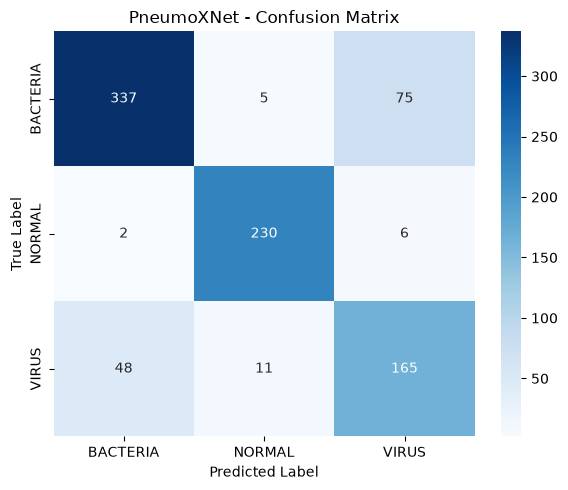

Confusion Matrix:
 [[337   5  75]
 [  2 230   6]
 [ 48  11 165]]


In [6]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("PneumoXNet - Confusion Matrix")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pneumoxnet_confusion_matrix_seed42.png", dpi=220, bbox_inches="tight")
plt.show()

print("Confusion Matrix:\n", cm)

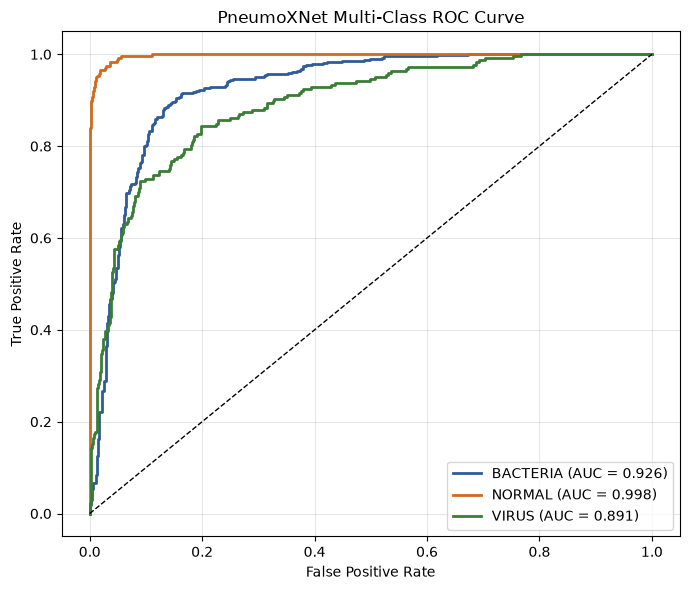

In [7]:
y_true_bin = label_binarize(all_labels, classes=[0, 1, 2])

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#2E5C99", "#D2691E", "#3A7D34"]

for i, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[i], lw=2, label=f"{class_name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("PneumoXNet Multi-Class ROC Curve")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pneumoxnet_roc_curve_seed42.png", dpi=220, bbox_inches="tight")
plt.show()

In [8]:
from torchvision.models import resnet50, ResNet50_Weights, convnext_tiny, ConvNeXt_Tiny_Weights

def build_resnet50():
    model = resnet50(weights=ResNet50_Weights.DEFAULT)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(in_features, NUM_CLASSES))
    return model

def build_convnext_tiny():
    model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)
    return model

def build_efficientnet_b2():
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(in_features, NUM_CLASSES))
    return model

BASELINE_BUILDERS = {
    "EfficientNet-B2": (build_efficientnet_b2, PROJECT_DIR / "models" / "efficientnetb2_seed42_best.pth"),
    "ResNet-50":       (build_resnet50,        PROJECT_DIR / "models" / "resnet50_seed42_best.pth"),
    "ConvNeXt-Tiny":   (build_convnext_tiny,   PROJECT_DIR / "models" / "convnexttiny_seed42_best.pth"),
}

baseline_perclass_results = []

for model_name, (builder_fn, ckpt_path) in BASELINE_BUILDERS.items():
    print("=" * 70)
    print(f"Evaluating {model_name} (seed42) on test set")
    print("=" * 70)

    model = builder_fn().to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()

    b_labels, b_preds = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            b_labels.extend(labels.numpy().tolist())
            b_preds.extend(preds.cpu().numpy().tolist())

    acc = (np.array(b_labels) == np.array(b_preds)).mean()
    report = classification_report(b_labels, b_preds, target_names=CLASS_NAMES, digits=4, output_dict=True)

    print(f"Accuracy: {acc*100:.2f}%")
    print(classification_report(b_labels, b_preds, target_names=CLASS_NAMES, digits=4))

    baseline_perclass_results.append({
        "model": model_name,
        "accuracy": round(acc * 100, 2),
        "BACTERIA_F1": round(report["BACTERIA"]["f1-score"], 4),
        "NORMAL_F1": round(report["NORMAL"]["f1-score"], 4),
        "VIRUS_F1": round(report["VIRUS"]["f1-score"], 4),
    })

    del model
    torch.cuda.empty_cache()

print("=" * 70)
print("Table V Summary (all models, seed42)")
print("=" * 70)
pneumoxnet_row = {
    "model": "PneumoXNet",
    "accuracy": round(test_accuracy * 100, 2),
    "BACTERIA_F1": round(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4, output_dict=True)["BACTERIA"]["f1-score"], 4),
    "NORMAL_F1": round(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4, output_dict=True)["NORMAL"]["f1-score"], 4),
    "VIRUS_F1": round(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4, output_dict=True)["VIRUS"]["f1-score"], 4),
}
table_v_df = pd.DataFrame(baseline_perclass_results + [pneumoxnet_row])
print(table_v_df.to_string(index=False))

Evaluating EfficientNet-B2 (seed42) on test set
Accuracy: 85.21%
              precision    recall  f1-score   support

    BACTERIA     0.8622    0.8705    0.8663       417
      NORMAL     0.9347    0.9622    0.9482       238
       VIRUS     0.7371    0.7009    0.7185       224

    accuracy                         0.8521       879
   macro avg     0.8447    0.8445    0.8444       879
weighted avg     0.8500    0.8521    0.8509       879

Evaluating ResNet-50 (seed42) on test set
Accuracy: 85.21%
              precision    recall  f1-score   support

    BACTERIA     0.8585    0.8585    0.8585       417
      NORMAL     0.9363    0.9874    0.9611       238
       VIRUS     0.7393    0.6964    0.7172       224

    accuracy                         0.8521       879
   macro avg     0.8447    0.8474    0.8456       879
weighted avg     0.8492    0.8521    0.8503       879

Evaluating ConvNeXt-Tiny (seed42) on test set
Accuracy: 85.10%
              precision    recall  f1-score   suppo